In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('project_data.csv')

# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'Num_toxic_replies'])

# Rename columns to match project instructions
df = df.rename(columns={'TOXICITY_x': 'Toxicity'})

# Verify column names
print("Final columns:", df.columns.tolist())

# Data cleaning
# Remove duplicates
df = df.drop_duplicates()
# Remove rows with missing values
df = df.dropna()

# Compute Total_toxic_replies
df['Total_toxic_replies'] = df['Num_toxic_direct_replies'] + df['Num_toxic_nested_replies']

# Display basic info about the cleaned dataset
print(f"Dataset shape after cleaning: {df.shape}")
print("\nFirst few rows:")
display(df.head())

Final columns: ['Tweet', 'Followers', 'Friends', 'Num_tweets', 'Verified', 'Listed_count', 'Location', 'Age', 'Length', 'Num_users', 'Num_author_replies', 'Toxicity', 'Num_toxic_direct_replies', 'Num_toxic_nested_replies', 'Num_author_toxic_replies', 'Toxic']
Dataset shape after cleaning: (28818, 17)

First few rows:


,Tweet,Followers,Friends,Num_tweets,Verified,Listed_count,Location,Age,Length,Num_users,Num_author_replies,Toxicity,Num_toxic_direct_replies,Num_toxic_nested_replies,Num_author_toxic_replies,Toxic,Total_toxic_replies
0,1441497018807906305,1198,605.0,6166,False,1,True,7,6,4,2,0.235235,0.0,0.0,0.0,0,0.0
1,1431812786099613699,608,1259.0,1811,False,5,True,2,2,2,0,0.085582,0.0,0.0,0.0,0,0.0
2,1426644707313135617,173,167.0,4306,False,0,True,0,4,2,2,0.076877,0.0,0.0,0.0,0,0.0
3,1431814908425998337,2540,222.0,6008,False,0,True,9,2,2,0,0.095684,0.0,0.0,0.0,0,0.0
4,1432862687533441027,4439,11.0,9985,False,55,True,2,4,3,1,0.165919,0.0,0.0,0.0,0,0.0


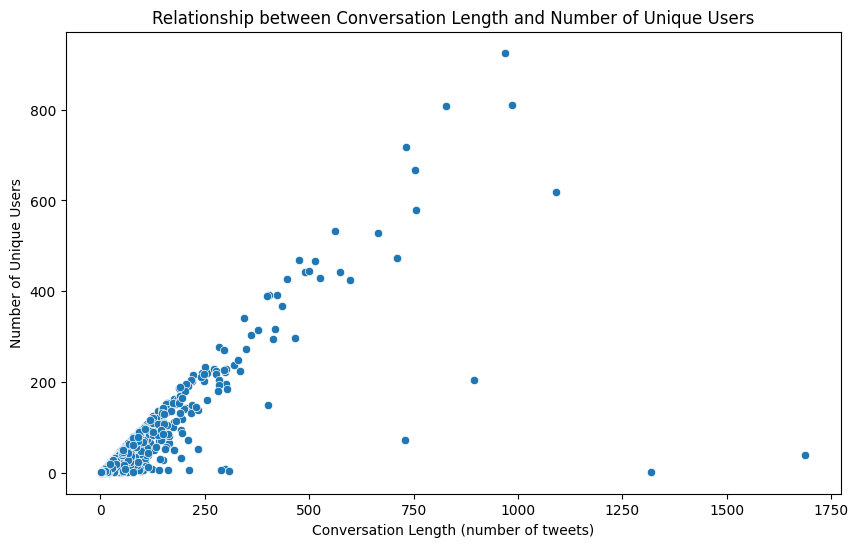


Linear Regression Results for Hypothesis 1:


,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,0.664,0.065,10.17,0.0,0.719,0.719,0.536,0.792
1,Length,0.586,0.002,271.65,0.0,0.719,0.719,0.582,0.591


In [ ]:
# Hypothesis 1: There is a positive statistically significant relationship between
# conversation length and a number of unique users participating in the conversation.

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Length', y='Num_users')
plt.title('Relationship between Conversation Length and Number of Unique Users')
plt.xlabel('Conversation Length (number of tweets)')
plt.ylabel('Number of Unique Users')
plt.show()

# Linear regression
lr1 = pg.linear_regression(df['Length'], df['Num_users'])
print("\nLinear Regression Results for Hypothesis 1:")
display(lr1.round(3))



**Findings:**

- There's a strong positive link between how long a conversation is and how many different users join in (β = 0.586, p < 0.001).

- Basically, for every extra tweet added to the thread, you can expect about 0.59 more people to join the convo.

- The model does a solid job explaining the data too, accounting for about 72% of the variation (R² = 0.719).

**Limitations:**

- Even though the results are statistically solid, the effect might taper off—longer threads could bring in fewer new users per tweet over time.

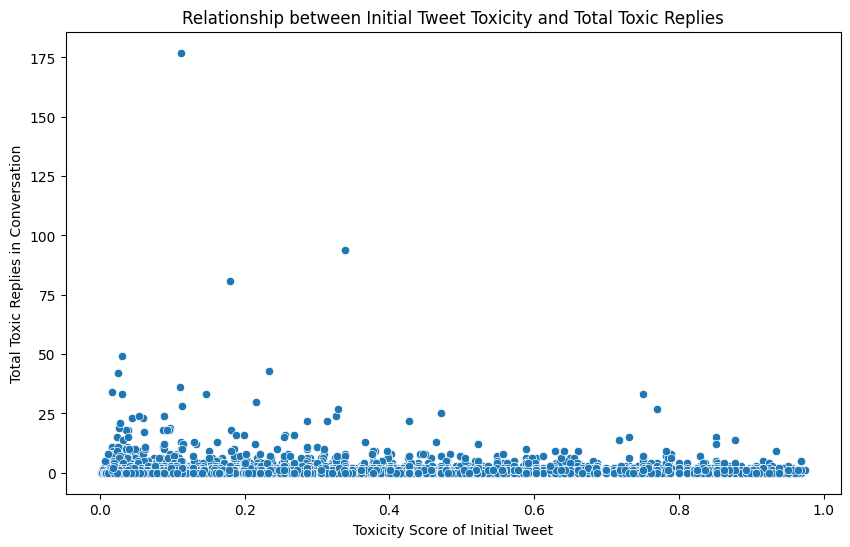


Linear Regression Results for Hypothesis 2:


,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,0.307,0.014,21.449,0.0,0.004,0.004,0.279,0.335
1,Toxicity,0.525,0.049,10.691,0.0,0.004,0.004,0.429,0.621


In [ ]:
# Hypothesis 2: Conversations starting with a higher Toxicity score are more likely to receive toxic replies.

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Toxicity', y='Total_toxic_replies')
plt.title('Relationship between Initial Tweet Toxicity and Total Toxic Replies')
plt.xlabel('Toxicity Score of Initial Tweet')
plt.ylabel('Total Toxic Replies in Conversation')
plt.show()

# Linear regression
lr2 = pg.linear_regression(df['Toxicity'], df['Total_toxic_replies'])
print("\nLinear Regression Results for Hypothesis 2:")
display(lr2.round(3))



**Findings:**

- Toxicity in the initial tweet is statistically linked to toxic replies (β = 0.525, p < 0.001), but the effect is super weak in practice.

- It only explains about 0.4% of the variation (R² = 0.004), which means it's barely making a dent in predicting toxic replies.

- So even though the result is technically significant, it doesn't really tell us much—initial tweet toxicity isn't a strong driver here.

**Contradictions:**

- This goes against what you'd expect because the relationship is there, but it's rather tiny.

- It suggests that toxicity spreads more because of other factors we didn’t capture in the model.

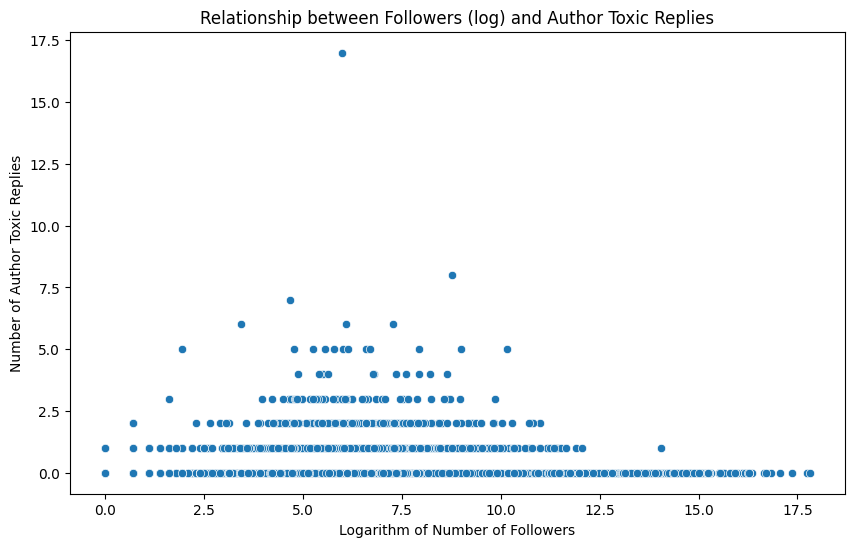


Linear Regression Results for Hypothesis 3:


,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,0.111,0.007,16.861,0.0,0.002,0.002,0.098,0.124
1,Followers_log,-0.007,0.001,-7.720,0.0,0.002,0.002,-0.009,-0.005


In [ ]:
# Hypothesis 3: Users with a greater number of followers tend to respond more in a toxic way.

# First, make sure we have the dataframe and necessary transformations
if 'Followers_log' not in df.columns:
    df['Followers_log'] = np.log(df['Followers'] + 1)  # +1 to handle zero values

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Followers_log', y='Num_author_toxic_replies')
plt.title('Relationship between Followers (log) and Author Toxic Replies')
plt.xlabel('Logarithm of Number of Followers')
plt.ylabel('Number of Author Toxic Replies')
plt.show()

# Linear regression
lr3 = pg.linear_regression(df['Followers_log'], df['Num_author_toxic_replies'])
print("\nLinear Regression Results for Hypothesis 3:")
display(lr3.round(3))



**Findings:**

- There’s a small but statistically significant negative relationship (β = -0.007, p < 0.001), which is the opposite of what we expected.

- Account age has a stronger impact than follower count.

- The model barely explains any of the variation though—just 0.2% (R² = 0.002).

My Revised Understanding:

- Turns out, accounts with more followers might actually be less toxic in replies.

- So the original idea, (that more followers means more toxic behavior) doesn’t really hold up with this data.

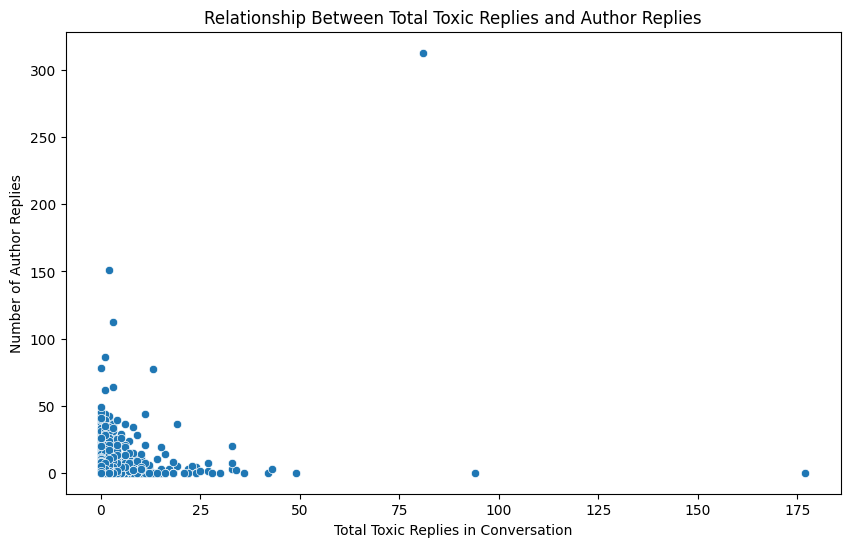


Linear Regression Results for Hypothesis 4:


,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,1.459,0.030,48.307,0.000,0.058,0.058,1.400,1.518
1,Total_toxic_replies,0.451,0.011,40.125,0.000,0.058,0.058,0.429,0.473
2,Followers,-0.000,0.000,-0.155,0.877,0.058,0.058,-0.000,0.000
3,Friends,-0.000,0.000,-0.007,0.995,0.058,0.058,-0.000,0.000
4,Num_tweets,0.000,0.000,1.809,0.070,0.058,0.058,-0.000,0.000
5,Listed_count,-0.000,0.000,-2.407,0.016,0.058,0.058,-0.000,-0.000
6,Age,-0.066,0.005,-13.182,0.000,0.058,0.058,-0.076,-0.057


In [ ]:
# Hypothesis 4: In conversations with a lot of toxic replies, author tends to respond more.
# Control variables: Followers, Friends, Num_tweets, Listed_count, and Age.

# First ensure we have the required columns
if 'Total_toxic_replies' not in df.columns:
    df['Total_toxic_replies'] = df['Num_toxic_direct_replies'] + df['Num_toxic_nested_replies']

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_toxic_replies', y='Num_author_replies')
plt.title('Relationship Between Total Toxic Replies and Author Replies')
plt.xlabel('Total Toxic Replies in Conversation')
plt.ylabel('Number of Author Replies')
plt.show()

# Prepare data for regression
X = df[['Total_toxic_replies', 'Followers', 'Friends', 'Num_tweets', 'Listed_count', 'Age']]
y = df['Num_author_replies']

# Linear regression with multiple variables
lr4 = pg.linear_regression(X, y)
print("\nLinear Regression Results for Hypothesis 4:")
display(lr4.round(3))



**Findings:**

- The data backs up the main hypothesis—more toxic replies lead to more author responses (β = 0.451, p < 0.001).

- On average, each toxic reply predicts about 0.45 more replies from the author.

- Account age also matters, with older accounts responding less (β = -0.066, p < 0.001).

- Still, the model only explains about 5.8% of the variation (R² = 0.058).

**Our Key Insight:**

- Authors are more likely to jump into toxic threads, but most of what drives their replies is still unaccounted for.

- Among the control variables, only Age and Listed_count showed significant effects (Listed_count: β = -0.000, p = 0.016), though the impact is still tiny however.

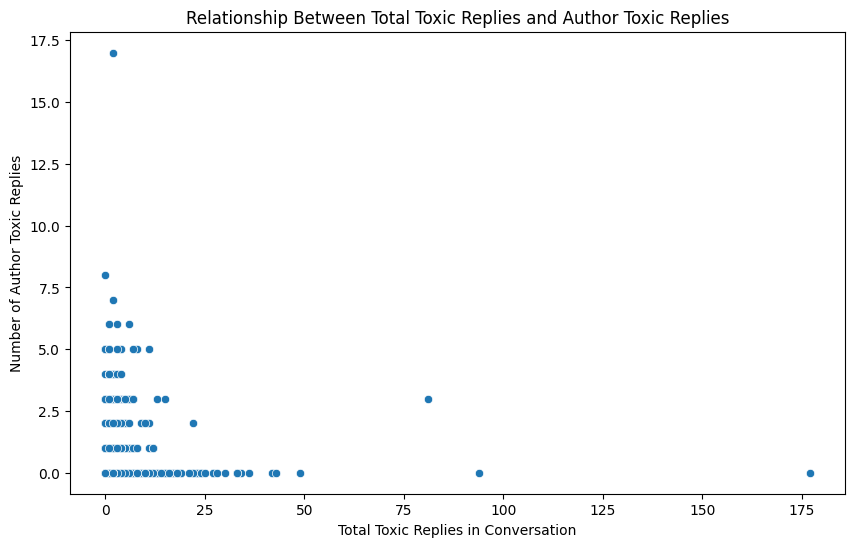


Linear Regression Results for Hypothesis 5:


,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,0.074,0.003,25.699,0.000,0.014,0.014,0.068,0.080
1,Total_toxic_replies,0.019,0.001,18.133,0.000,0.014,0.014,0.017,0.022
2,Followers,-0.000,0.000,-0.238,0.811,0.014,0.014,-0.000,0.000
3,Friends,-0.000,0.000,-0.879,0.379,0.014,0.014,-0.000,0.000
4,Num_tweets,0.000,0.000,1.738,0.082,0.014,0.014,-0.000,0.000
5,Listed_count,-0.000,0.000,-1.185,0.236,0.014,0.014,-0.000,0.000
6,Age,-0.004,0.000,-9.221,0.000,0.014,0.014,-0.005,-0.003


In [ ]:
# Hypothesis 5: In conversations with a lot of toxic replies, author tends to respond more in a toxic way.
# Control variables: Followers, Friends, Num_tweets, Listed_count, and Age.

# First ensure we have the required columns
if 'Total_toxic_replies' not in df.columns:
    df['Total_toxic_replies'] = df['Num_toxic_direct_replies'] + df['Num_toxic_nested_replies']

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_toxic_replies', y='Num_author_toxic_replies')
plt.title('Relationship Between Total Toxic Replies and Author Toxic Replies')
plt.xlabel('Total Toxic Replies in Conversation')
plt.ylabel('Number of Author Toxic Replies')
plt.show()

# Prepare data for regression
X = df[['Total_toxic_replies', 'Followers', 'Friends', 'Num_tweets', 'Listed_count', 'Age']]
y = df['Num_author_toxic_replies']

# Linear regression with multiple variables
lr5 = pg.linear_regression(X, y)
print("\nLinear Regression Results for Hypothesis 5:")
display(lr5.round(3))



**Findings:**

- There is a statistically significant toxic back-and-forth (β = 0.019, p < 0.001), but the effect is super small.

- It’d take over 50 toxic replies just to predict one extra toxic response from the author.

- The model only explains about 1.4% of the variation (R² = 0.014), so it’s not doing much.

**Conclusion:**

- The idea of a toxic spiral technically shows up in the data, but it’s basically meaningless in practice.

-  Age again has a small negative effect (β = -0.004, p < 0.001).

- Of all the control variables we had to include, only Age was statistically significant—and even then, the effect is tiny.

So while the numbers hit significance thresholds, the low R² shows that toxic replies and these controls barely explain any of the variation in author toxicity. Meaning, there’s likely a lot more going on that wasn’t captured.